# 신용카드사기탐지_모델만들기

* trans_date_trans_time : 거래 시간
* cc_num : 카드 번호. 고유값이기 때문에 여기서는 id처럼 활용할 수 있습니다.
* merchant : 거래 상점
* category : 거래 상점의 범주(애완용품, 여행, 엔터테인먼트 등)
* amt : 거래 금액
* first / last : 이름
* gender : 성별
* street / state / zip : 고객 거주지 정보
* lat / long : 고객 주소에 대한 위도 및 경도
* city_pop : 고객이 zipcode에 속하는 인구 수
* job : 직업
* dob : 생년월일
* trans_num : 거래번호
* unix_time : 거래 시간(유닉스 타임스탬프 형식)
* merch_lat / merch_long : 상점 위치에 대한 위도 및 경도
* is_fraud : 사기거래 여부 (종속변수)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
# 인텔 cpu 사용하는 경우, skleran 최적화 시켜주는 패키지
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
data = pd.read_csv('./data/fraud.csv')
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
data.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0


In [5]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1852394 non-null  object 
 1   cc_num                 1852394 non-null  int64  
 2   merchant               1852394 non-null  object 
 3   category               1852394 non-null  object 
 4   amt                    1852394 non-null  float64
 5   first                  1852394 non-null  object 
 6   last                   1852394 non-null  object 
 7   gender                 1852394 non-null  object 
 8   street                 1852394 non-null  object 
 9   city                   1852394 non-null  object 
 10  state                  1852394 non-null  object 
 11  zip                    1852394 non-null  int64  
 12  lat                    1852394 non-null  float64
 13  long                   1852394 non-null  float64
 14  city_pop          

In [6]:
data[['amt', 'city_pop']].describe()

,amt,city_pop
count,1852394.000,1852394.000
mean,70.064,88643.675
std,159.254,301487.618
min,1.000,23.000
25%,9.640,741.000
50%,47.450,2443.000
75%,83.100,20328.000
max,28948.900,2906700.000


In [7]:
# 문자형, 숫자형 DF 분류하기
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [8]:
obj_cols.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [9]:
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print("nunique: ", obj_cols[col].nunique(), end="\n\n")
    print(obj_cols[col].value_counts(), end="\n\n")
    print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False), end="\n\n")

============================== trans_date_trans_time ==============================
nunique:  1819551

trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:41:45    1
2019-01-01 00:42:26    1
2019-01-01 00:43:38    1
2019-01-01 00:44:20    1
2020-12-31 23:50:17    1
Name: count, Length: 1819551, dtype: int64

                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11       1.000
2019-12-22 01:09:30       1.000
2019-02-12 23:49:17       1.000
2019-09-23 06:33:47       1.000
2019-05-03 04:38:52       1.000
...                         ...
2019-01-01 00:41:45       0.000
2019-01-01 00:42:26       0.000
2019-01-01 00:43:38       0.000
2019-01-01 00:44:20       0.000
2020-12-31 23:50:17       0.000

[1819551 rows x 1 columns]

============================== merchant ==============================
nunique:  693

merchant
fraud_Kilback LL

nunique:  984

dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1962-03-14       7
1944-06-17       7
1970-06-25       7
1932-05-09       7
1998-08-02       6
Name: count, Length: 984, dtype: int64

            is_fraud
dob                 
2001-07-17     1.000
2002-03-17     1.000
1925-08-29     1.000
1927-02-03     1.000
1944-05-30     1.000
...              ...
1949-10-04     0.000
1975-04-16     0.000
1973-10-19     0.000
1975-06-29     0.000
1930-02-28     0.000

[984 rows x 1 columns]

============================== trans_num ==============================
nunique:  1852394

trans_num
1765bb45b3aa3224b4cdcb6e7a96cee3    1
0b242abb623afc578575680df30655b9    1
1f76529f8574734946361c461b024d99    1
a1a22d70485983eac12b5b88dad1cf95    1
6b849c168bdad6f867558c3793159a81    1
                                   ..
413636e759663f264aae1819a4d4f231    1
8a6293af5ed278dea14448ded2685fea    1
baae0b096835c975857eea7e28dde

In [11]:
data[data['state'] == 'DE']

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
233631,2019-04-28 00:41:37,6011826317034777,fraud_Schamberger-O'Keefe,grocery_pos,294.910,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,8f85e701f609911b99bea627eb71aa49,1335573697,38.167,-75.023,1
233744,2019-04-28 01:49:28,6011826317034777,fraud_Kuphal-Predovic,misc_net,868.290,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,8c941f2849ccac44d32ef08ea784fc67,1335577768,38.911,-74.857,1
233826,2019-04-28 02:33:09,6011826317034777,fraud_Goodwin-Nitzsche,grocery_pos,280.260,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,0fc1109cb9a10961595e79736ccc1293,1335580389,38.523,-74.461,1
234625,2019-04-28 10:24:34,6011826317034777,"fraud_Huel, Hammes and Witting",grocery_pos,296.250,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,b4248cfc8b44fec6193767918d49b334,1335608674,38.594,-76.031,1
236522,2019-04-28 23:03:24,6011826317034777,fraud_Waters-Cruickshank,health_fitness,20.580,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,567ed9b2d7d10ad519cdd697cd338f70,1335654204,39.004,-75.852,1
236643,2019-04-28 23:41:43,6011826317034777,fraud_Cormier LLC,shopping_net,1012.770,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,00d158609d7ac753da792e9d0eb88a0b,1335656503,39.596,-75.559,1
237095,2019-04-29 03:29:41,6011826317034777,fraud_Ruecker Group,misc_net,885.960,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,e0613e4142b2d05867299832ac453e01,1335670181,39.666,-76.359,1
237740,2019-04-29 10:13:47,6011826317034777,fraud_Smitham-Schiller,grocery_net,10.930,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,788a8fea8199a4e8a6a47ffab824e571,1335694427,37.692,-76.058,1
239854,2019-04-29 23:51:22,6011826317034777,"fraud_Baumbach, Feeney and Morar",shopping_net,960.490,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,4193b953223a1c9432f9d3c380e67be9,1335743482,39.073,-75.545,1


trans_date_trans_time', 'merchant', 'category', 'gender', 'job'

In [12]:
from ydata_profiling import ProfileReport

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
profile = ProfileReport(data, title="Profiling Report")

In [ ]:
profile.to_file("is_fraud_eda.html")

* 집위치와 상점 위치가 서로 연관이 있다.
* cc_num 의 유일값이 999개다.

In [15]:
data['cc_num'].nunique()

999

is_froad의 비율

In [10]:
data['is_fraud'].mean() * 100

np.float64(0.5210014716091717)

# 카드별(고객) 거래 금액에서의 이상치 찾고 is_fraud와의 관계 보기

In [17]:
amt_desc = data.groupby(['cc_num'])['amt'].describe()
amt_desc

,count,mean,std,min,25%,50%,75%,max
cc_num,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460
...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430


In [18]:
amt_desc.columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='object')

In [19]:
amt_desc['iqr_max'] = amt_desc['75%'] + (1.5 * (amt_desc['75%'] - amt_desc['25%']))
amt_desc

,count,mean,std,min,25%,50%,75%,max,iqr_max
cc_num,,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946


In [20]:
amt_desc = amt_desc.reset_index()
amt_desc

,cc_num,count,mean,std,min,25%,50%,75%,max,iqr_max
0,60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
1,60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
2,60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
3,60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
4,60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
995,4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
996,4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946
997,4989847570577635369,1471.000,93.009,128.397,1.030,19.940,57.170,111.945,1223.850,249.952


# 원본 data와 그룹연산결과 합치기

In [21]:
amt_desc.columns

Index(['cc_num', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
       'iqr_max'],
      dtype='object')

In [22]:
amt_desc.columns = ['cc_num', 'count', 'amt_mean', 'amt_std', 'min', '25%', '50%', '75%', 'max',
       'amt_iqr_max']

In [23]:
data = pd.merge(data, amt_desc[['cc_num', 'amt_mean', 'amt_std', 'amt_iqr_max']], how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.947,-91.333,0,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661,-96.187,0,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658,-119.715,0,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.471,-117.081,0,60.998,89.526,186.940


In [24]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max'],
      dtype='object')

In [25]:
data = data.drop(['first', 'last', 'street', 'city', 'state', 'zip', 'trans_num', 'unix_time'], axis=1)
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940


In [26]:
data.loc[data['amt'] > data['amt_iqr_max'], 'is_fraud'].mean() * 100

np.float64(8.316776198481838)

# 사용금액의 z-score를 구한 후 사기 비율 계산
* z-score: (값 - 평균) / 표준편차 = -3 > , 3>

In [27]:
data['amt_zscore'] = (data['amt'] - data['amt_mean']) / data['amt_std']

In [28]:
data['amt_zscore']

0         -0.662
1          0.321
2          1.287
3         -0.125
4         -0.566
           ...  
1852389   -0.168
1852390    0.365
1852391   -0.015
1852392   -0.592
1852393   -0.153
Name: amt_zscore, Length: 1852394, dtype: float64

In [29]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore
138,2019-01-01 01:41:22,4060579726528237,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,636.410,M,39.214,-95.440,2661,Theatre director,1948-11-14,39.937,-94.604,0,68.593,125.466,202.980,4.526
139,2019-01-01 01:41:24,4186530744674,fraud_Rempel Inc,shopping_net,500.920,F,33.364,-81.272,4913,Technical brewer,1966-11-10,34.328,-81.728,0,67.400,118.319,200.014,3.664
232,2019-01-01 02:54:10,4311368326621416041,fraud_Kassulke PLC,shopping_net,1055.470,M,40.769,-103.097,648,Community arts worker,1969-09-21,39.941,-103.528,0,62.139,92.234,192.765,10.770
259,2019-01-01 03:15:26,4988304376504,fraud_Christiansen-Gusikowski,misc_pos,464.740,M,41.458,-74.166,2258,Building surveyor,1937-03-17,41.430,-74.521,0,63.753,115.162,183.245,3.482
296,2019-01-01 03:51:28,571844099986,fraud_Heathcote LLC,shopping_net,909.660,F,38.251,-85.748,736284,Engineering geologist,1952-04-02,39.081,-86.302,0,67.430,115.371,200.558,7.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852163,2020-12-31 22:34:06,4841313716651064,fraud_Fritsch LLC,travel,500.310,M,43.718,-72.444,140,"Development worker, community",1989-10-28,44.390,-71.547,0,95.576,94.743,148.178,4.272
1852170,2020-12-31 22:36:21,630451534402,fraud_Gleason-Macejkovic,shopping_net,850.870,F,46.353,-86.635,765,Immunologist,1972-06-12,45.905,-86.690,0,60.869,259.284,166.037,3.047
1852198,2020-12-31 22:49:09,2254917871818484,fraud_Jast-McDermott,shopping_pos,516.740,F,38.083,-76.348,313,Insurance underwriter,1976-03-26,38.853,-76.567,0,58.550,130.447,173.965,3.512
1852304,2020-12-31 23:26:42,2248735346244816,fraud_Crooks and Sons,personal_care,302.790,M,38.641,-100.138,269,Product/process development scientist,1962-11-11,37.949,-99.767,0,57.125,75.475,178.612,3.255


In [30]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    21725
1     4092
Name: count, dtype: int64

In [31]:
4092 / (4092 + 21725) * 100

15.850021303792076

In [32]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].mean() * 100

np.float64(15.850021303792076)

# 사용자가 어디에 주로 지출하는가?
* 식품에 지출이 많은 사람, 레저용품에 지출을 갑자기 많이 한다?
* 평소 지출하는 카테고리 혹은 가게가 아닌 경우
* 카드 번호별, 카테고리별 지출 평균, 표준편차

In [33]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore'],
      dtype='object')

In [34]:
cat_amt = data.groupby(['cc_num', 'category'])['amt'].agg(['mean', 'std']).reset_index()
cat_amt

,cc_num,category,mean,std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [35]:
cat_amt.columns = ['cc_num', 'category', 'cat_amt_mean', 'cat_amt_std']
cat_amt

,cc_num,category,cat_amt_mean,cat_amt_std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [36]:
data = pd.merge(data, cat_amt, how='left', on=['cc_num', 'category'])
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244


In [38]:
data['cat_amt_zscore'] = (data['amt'] - data['cat_amt_mean']) / data['cat_amt_std']

In [39]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,0.318
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,2.873
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,1.313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,1.164
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,0.440
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007


In [40]:
data[(data['cat_amt_zscore'] < -3) | (data['cat_amt_zscore'] > 3)]['is_fraud'].mean() * 100

np.float64(19.290895447723862)

In [41]:
data[(data['cat_amt_zscore'] < -3) | (data['cat_amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    25814
1     6170
Name: count, dtype: int64

# 집의 위치와 가게의 위치 상관관계 높음
* 집과 가게의 거리를 위도 경도 데이터를 이용해 계산해서 평균 거리를 초과하는 곳에서 일어난 거래를 통해 부당 거래 검출

In [42]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

# geopy 를 이용해 위도 경도 정보로 집과 가게의 거리 계산하기

In [43]:
from geopy import distance

In [44]:
from geopy.distance import distance

In [45]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

In [47]:
data['home_merch_dist'] = data.apply(lambda x: distance((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km, axis=1)
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688,78.774
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,0.318,30.217
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,2.873,108.103
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050,95.685
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,1.313,77.702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048,77.032
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,1.164,100.024
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,0.440,80.888
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007,53.061


In [48]:
dist_desc = data.groupby('cc_num')['home_merch_dist'].agg(['mean', 'std']).reset_index()
dist_desc

,cc_num,mean,std
0,60416207185,73.535,28.698
1,60422928733,78.986,29.299
2,60423098130,77.827,28.188
3,60427851591,75.712,28.977
4,60487002085,79.443,28.767
...,...,...,...
994,4958589671582726883,76.736,29.124
995,4973530368125489546,78.754,29.451
996,4980323467523543940,72.272,28.280
997,4989847570577635369,76.970,29.387


In [49]:
dist_desc.columns = ['cc_num', 'dist_mean', 'dist_std']
dist_desc

,cc_num,dist_mean,dist_std
0,60416207185,73.535,28.698
1,60422928733,78.986,29.299
2,60423098130,77.827,28.188
3,60427851591,75.712,28.977
4,60487002085,79.443,28.767
...,...,...,...
994,4958589671582726883,76.736,29.124
995,4973530368125489546,78.754,29.451
996,4980323467523543940,72.272,28.280
997,4989847570577635369,76.970,29.387


In [50]:
data = pd.merge(data, dist_desc, how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688,78.774,77.842,30.072
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,0.318,30.217,71.657,28.091
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,2.873,108.103,74.581,28.884
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050,95.685,72.049,28.892
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,1.313,77.702,75.836,29.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048,77.032,75.524,28.959
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,1.164,100.024,79.173,30.051
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,0.440,80.888,72.656,28.552
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007,53.061,73.689,28.255


In [51]:
print(distance((data['lat'][0], data['long'][0]), (data['merch_lat'][0], data['merch_long'][0])).km)

78.77382075373654


In [52]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std'],
      dtype='object')

In [53]:
data['dist_zscore'] = (data['home_merch_dist'] - data['dist_mean']) / data['dist_std']

In [54]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]['is_fraud'].mean() * 100

nan

In [55]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std,dist_zscore


In [56]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std', 'dist_zscore'],
      dtype='object')

In [57]:
data = data.drop(['amt_mean', 'amt_std',  'cat_amt_mean', 'cat_amt_std', 
           'dist_mean', 'dist_std', 'merchant', 'lat', 'long', 
           'merch_lat', 'merch_long', 'cc_num', ], axis=1)

In [58]:
data.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city_pop', 'job',
       'dob', 'is_fraud', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore'],
      dtype='object')

# 나이 추출

In [66]:
data['age'] = data['dob'].apply(lambda x: 2020 - int(x[:4]))

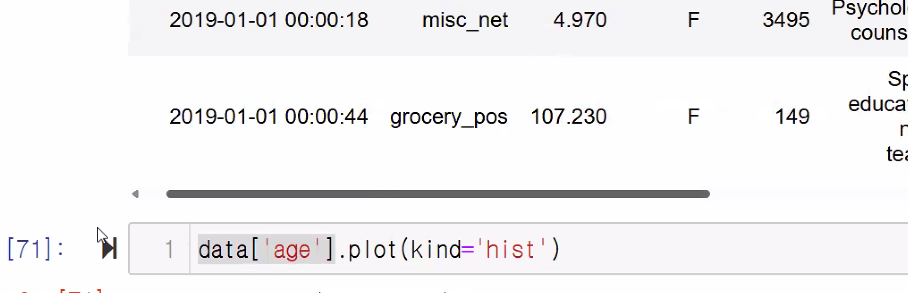

<Axes: ylabel='Frequency'>

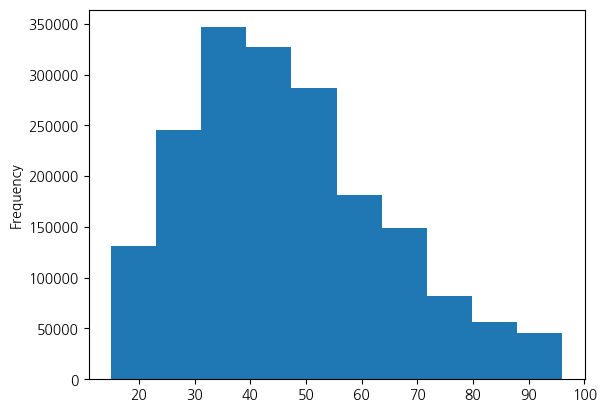

In [69]:
data['age'].plot(kind='hist')

In [70]:
data.groupby('age')['is_fraud'].mean().sort_values(ascending=False)

age
18   1.000
95   1.000
88   0.016
77   0.012
80   0.012
24   0.011
86   0.010
63   0.010
96   0.010
57   0.009
83   0.009
59   0.009
52   0.009
79   0.009
93   0.008
56   0.008
84   0.008
82   0.007
19   0.007
81   0.007
78   0.007
71   0.007
92   0.007
62   0.007
60   0.007
68   0.007
87   0.007
73   0.007
74   0.007
64   0.006
53   0.006
58   0.006
61   0.006
85   0.006
34   0.006
89   0.006
54   0.006
72   0.006
75   0.006
91   0.006
51   0.006
50   0.006
20   0.006
67   0.006
70   0.006
22   0.006
55   0.005
38   0.005
25   0.005
29   0.005
23   0.005
21   0.005
27   0.005
26   0.005
30   0.005
66   0.005
44   0.005
76   0.005
90   0.004
39   0.004
43   0.004
33   0.004
69   0.004
65   0.004
46   0.004
28   0.004
37   0.004
31   0.004
49   0.004
48   0.004
94   0.004
41   0.004
47   0.004
17   0.004
32   0.004
42   0.003
40   0.003
35   0.003
36   0.003
45   0.003
16   0.003
15   0.002
Name: is_fraud, dtype: float64

In [76]:
data.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city_pop', 'job',
       'dob', 'is_fraud', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age'],
      dtype='object')

'trans_date_trans_time', 'dob' 삭제

In [78]:
data = data.drop(['trans_date_trans_time', 'dob'], axis=1)

# 종속변수, 독립변수 분리, 훈련, 테스트 데이터로 나누기

In [79]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [80]:
X.columns

Index(['category', 'amt', 'gender', 'city_pop', 'job', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_zscore', 'home_merch_dist', 'dist_zscore',
       'age'],
      dtype='object')

In [96]:
X = pd.get_dummies(X, drop_first=True)

In [81]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0          0
1          0
2          0
3          0
4          0
          ..
1852389    0
1852390    0
1852391    0
1852392    0
1852393    0
Name: is_fraud, Length: 1852394, dtype: int64>

In [86]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

* 홀드아웃, train, valid, test

In [97]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [99]:
print(len(X_train), len(X_valid), len(X_test))

1111436 370479 370479


In [100]:
print(y_train.value_counts())

is_fraud
0    1105645
1       5791
Name: count, dtype: int64


In [101]:
print(y_valid.value_counts())

is_fraud
0    368549
1      1930
Name: count, dtype: int64


In [102]:
print(y_test.value_counts())

is_fraud
0    368549
1      1930
Name: count, dtype: int64


In [103]:
print(y_train.value_counts())

is_fraud
0    1105645
1       5791
Name: count, dtype: int64


In [104]:
X

,amt,city_pop,amt_iqr_max,amt_zscore,cat_amt_zscore,home_merch_dist,dist_zscore,age,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,"job_Accountant, chartered","job_Accountant, chartered certified","job_Accountant, chartered public finance",job_Accounting technician,job_Acupuncturist,job_Administrator,"job_Administrator, arts","job_Administrator, charities/voluntary organisations","job_Administrator, education","job_Administrator, local government",job_Advertising account executive,job_Advertising account planner,job_Advertising copywriter,job_Advice worker,job_Aeronautical engineer,job_Agricultural consultant,job_Aid worker,job_Air broker,job_Air cabin crew,job_Air traffic controller,job_Airline pilot,job_Ambulance person,job_Amenity horticulturist,job_Analytical chemist,job_Animal nutritionist,job_Animal technologist,job_Animator,job_Applications developer,job_Arboriculturist,job_Archaeologist,job_Architect,job_Architectural technologist,job_Archivist,job_Armed forces logistics/support/administrative officer,job_Armed forces technical officer,job_Armed forces training and education officer,job_Art gallery manager,job_Art therapist,job_Artist,job_Arts development officer,job_Associate Professor,job_Audiological scientist,job_Barista,job_Barrister,job_Barrister's clerk,"job_Biochemist, clinical",job_Biomedical engineer,job_Biomedical scientist,job_Bookseller,job_Broadcast engineer,job_Broadcast journalist,job_Broadcast presenter,job_Building control surveyor,job_Building services engineer,job_Building surveyor,"job_Buyer, industrial","job_Buyer, retail",job_Cabin crew,job_Call centre manager,job_Camera operator,job_Careers adviser,job_Careers information officer,job_Cartographer,job_Catering manager,job_Ceramics designer,job_Charity fundraiser,job_Charity officer,job_Chartered accountant,job_Chartered legal executive (England and Wales),job_Chartered loss adjuster,job_Chartered public finance accountant,job_Chemical engineer,"job_Chemist, analytical",job_Chief Executive Officer,job_Chief Financial Officer,job_Chief Marketing Officer,job_Chief Operating Officer,job_Chief Strategy Officer,job_Chief Technology Officer,job_Chief of Staff,job_Child psychotherapist,job_Chiropodist,job_Civil Service administrator,job_Civil Service fast streamer,"job_Civil engineer, contracting",job_Claims inspector/assessor,job_Clinical biochemist,job_Clinical cytogeneticist,job_Clinical psychologist,job_Clinical research associate,job_Clothing/textile technologist,job_Colour technologist,job_Commercial horticulturist,job_Commercial/residential surveyor,job_Commissioning editor,job_Communications engineer,job_Community arts worker,job_Community development worker,job_Community education officer,job_Community pharmacist,job_Company secretary,job_Comptroller,"job_Conservation officer, historic buildings","job_Conservator, furniture","job_Conservator, museum/gallery",job_Contracting civil engineer,job_Contractor,job_Control and instrumentation engineer,job_Copy,"job_Copywriter, advertising",job_Corporate investment banker,job_Counselling psychologist,job_Counsellor,job_Curator,job_Cytogeneticist,job_Dance movement psychotherapist,job_Dancer,job_Data scientist,job_Database administrator,job_Dealer,"job_Designer, ceramics/pottery","job_Designer, exhibition/display","job_Designer, furniture","job_Designer, industrial/product","job_Designer, interior/spatial","job_Designer, jewellery","job_Designer, multimedia","job_Designer, television/film set","job_Designer, textile","job_Development worker, community","job_Development worker, international aid",job_Diagnostic radiographer,job_Dispensing optician,"job_Doctor, general practice","job_Doctor, hospital",job_Drilling engineer,job_Early years teacher,job_Ecologist,job_Economist,"job_Editor, 

In [105]:
X_train.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual merchandiser', 'job_Volunteer coordinator',
       'job_Warden/ranger', 'job_Warehouse manager',
       'job_Waste management officer', 'job_Water engineer',
       'job_Water quality scientist', 'job_Web designer',
       'job_Wellsite geologist', 'job_Writer'],
      dtype='object', length=518)

의사결정 나무로 분석하기

In [109]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" * 30, "test_result", "=" * 30)
test_pred = dtc.predict(X_test)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.61      0.67      0.64      1930

    accuracy                           1.00    370479
   macro avg       0.81      0.83      0.82    370479
weighted avg       1.00      1.00      1.00    370479

============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.63      0.69      0.66      1930

    accuracy                           1.00    370479
   macro avg       0.81      0.84      0.83    370479
weighted avg       1.00      1.00      1.00    370479



In [108]:
for i in range(1,11):
    dtc = DecisionTreeClassifier(max_depth=i, class_weight='balanced', random_state=42)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_valid)
    print(classification_report(y_valid, pred))
    print("=" * 30, f"test_result {i}", "=" * 30)
    test_pred = dtc.predict(X_test)
    print(classification_report(y_test, test_pred))
    print()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.12      0.75      0.21      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.86      0.60    370479
weighted avg       0.99      0.97      0.98    370479

============================== test_result 1 ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.13      0.77      0.22      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.87      0.60    370479
weighted avg       0.99      0.97      0.98    370479


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.15      0.84      0.25      1930

    accuracy                           0.97    370479
   macro avg       0.57      0.91      0.62    3704

In [110]:
print(dtc.get_params())

{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [114]:
importance = pd.DataFrame(dtc.feature_importances_, columns=['importance'])
colum_name = pd.DataFrame(dtc.feature_importances_, columns=['column'])

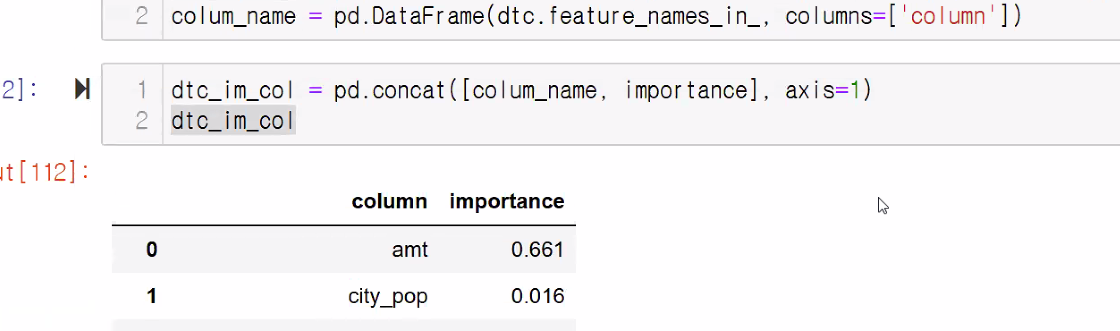

In [115]:
dtc_im_col = pd.concat([colum_name, importance], axis=1)
dtc_im_col

,column,importance
0,0.661,0.661
1,0.016,0.016
2,0.012,0.012
3,0.008,0.008
4,0.162,0.162
...,...,...
513,0.000,0.000
514,0.000,0.000
515,0.000,0.000
516,0.000,0.000


In [116]:
dtc_im_col.sort_values(by='importance', ascending=False)

,column,importance
0,0.661,0.661
4,0.162,0.162
7,0.020,0.020
1,0.016,0.016
10,0.014,0.014
...,...,...
88,0.000,0.000
425,0.000,0.000
428,0.000,0.000
22,0.000,0.000


In [118]:
dtc_im_col.sort_values(by='importance', ascending=False).head(20)

,column,importance
0,0.661,0.661
4,0.162,0.162
7,0.020,0.020
1,0.016,0.016
10,0.014,0.014
2,0.012,0.012
11,0.012,0.012
20,0.012,0.012
8,0.011,0.011
13,0.011,0.011


random_forest로 분석하기

In [120]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = rfc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.84      0.64      0.73      1930

    accuracy                           1.00    370479
   macro avg       0.92      0.82      0.86    370479
weighted avg       1.00      1.00      1.00    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.86      0.65      0.74      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.83      0.87    370479
weighted avg       1.00      1.00      1.00    370479




In [126]:
# 각 트리의 실제 max_depth 출력
depths = [estimator.tree_.max_depth for estimator in rfc.estimators_]
print("각 트리의 최대 깊이 목록:", depths)
print("평균 깊이:", sum(depths) / len(depths))
print("최댓값:", max(depths), " / 최솟값:", min(depths))

각 트리의 최대 깊이 목록: [210, 137, 112, 154, 160, 220, 162, 171, 207, 208, 178, 166, 247, 213, 158, 152, 198, 169, 198, 161, 178, 165, 166, 146, 202, 171, 135, 174, 160, 138, 207, 127, 127, 166, 142, 158, 188, 214, 186, 148, 206, 227, 190, 158, 167, 181, 139, 158, 157, 175, 146, 148, 203, 218, 230, 147, 235, 215, 167, 183, 190, 131, 198, 132, 159, 188, 224, 190, 162, 153, 140, 141, 122, 143, 129, 164, 150, 126, 128, 231, 134, 197, 209, 136, 192, 124, 214, 193, 173, 148, 143, 138, 195, 210, 130, 226, 162, 222, 202, 215]
평균 깊이: 172.93
최댓값: 247  / 최솟값: 112


In [124]:
print(dtc.tree_.max_depth)

204


XGBOOST로 분석하기

In [127]:
y_train.value_counts()

is_fraud
0    1105645
1       5791
Name: count, dtype: int64

* XGBoost 에서 소수 클래스에 가중치 줄 때 값 계산
* scale_pos_weight = n_negative / n_positive

In [129]:
1105645 / 5791

190.92471075807288

In [130]:
xgb = XGBClassifier(scale_pos_weight=190, n_jobs=10, random_state=42,  )
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=10,
              num_parallel_tree=None, random_state=42, ...)

In [133]:
%%time
xgb = XGBClassifier(scale_pos_weight=190, n_jobs=10, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = xgb.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.31      1930

    accuracy                           0.98    370479
   macro avg       0.59      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.32      1930

    accuracy                           0.98    370479
   macro avg       0.60      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


CPU times: total: 4min 22s
Wall time: 52.4 s


catboost

In [137]:
%%time
cbc = CatBoostClassifier(class_weights=[1, 190],  thread_count=10, random_state=42)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = cbc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

Learning rate set to 0.205839
0:	learn: 0.4764484	total: 289ms	remaining: 4m 48s
1:	learn: 0.3813003	total: 430ms	remaining: 3m 34s
2:	learn: 0.3110306	total: 583ms	remaining: 3m 13s
3:	learn: 0.2747007	total: 744ms	remaining: 3m 5s
4:	learn: 0.2394786	total: 951ms	remaining: 3m 9s
5:	learn: 0.2194895	total: 1.13s	remaining: 3m 7s
6:	learn: 0.1965085	total: 1.26s	remaining: 2m 58s
7:	learn: 0.1870707	total: 1.4s	remaining: 2m 53s
8:	learn: 0.1720559	total: 1.55s	remaining: 2m 51s
9:	learn: 0.1628529	total: 1.66s	remaining: 2m 44s
10:	learn: 0.1550960	total: 1.79s	remaining: 2m 41s
11:	learn: 0.1478856	total: 1.92s	remaining: 2m 38s
12:	learn: 0.1349576	total: 2.04s	remaining: 2m 34s
13:	learn: 0.1306729	total: 2.15s	remaining: 2m 31s
14:	learn: 0.1274014	total: 2.27s	remaining: 2m 29s
15:	learn: 0.1220365	total: 2.4s	remaining: 2m 27s
16:	learn: 0.1152573	total: 2.53s	remaining: 2m 26s
17:	learn: 0.1135054	total: 2.64s	remaining: 2m 24s
18:	learn: 0.1093977	total: 2.76s	remaining: 2m 2

160:	learn: 0.0502463	total: 20.9s	remaining: 1m 49s
161:	learn: 0.0501388	total: 21s	remaining: 1m 48s
162:	learn: 0.0500349	total: 21.2s	remaining: 1m 48s
163:	learn: 0.0498887	total: 21.3s	remaining: 1m 48s
164:	learn: 0.0497550	total: 21.4s	remaining: 1m 48s
165:	learn: 0.0495169	total: 21.5s	remaining: 1m 48s
166:	learn: 0.0492263	total: 21.6s	remaining: 1m 47s
167:	learn: 0.0491267	total: 21.7s	remaining: 1m 47s
168:	learn: 0.0489817	total: 21.9s	remaining: 1m 47s
169:	learn: 0.0488549	total: 22s	remaining: 1m 47s
170:	learn: 0.0487739	total: 22.1s	remaining: 1m 47s
171:	learn: 0.0486293	total: 22.2s	remaining: 1m 46s
172:	learn: 0.0485580	total: 22.3s	remaining: 1m 46s
173:	learn: 0.0484898	total: 22.4s	remaining: 1m 46s
174:	learn: 0.0484071	total: 22.5s	remaining: 1m 46s
175:	learn: 0.0483475	total: 22.7s	remaining: 1m 46s
176:	learn: 0.0482569	total: 22.8s	remaining: 1m 46s
177:	learn: 0.0481673	total: 22.9s	remaining: 1m 45s
178:	learn: 0.0476937	total: 23.1s	remaining: 1m 4

317:	learn: 0.0351903	total: 40.3s	remaining: 1m 26s
318:	learn: 0.0351215	total: 40.4s	remaining: 1m 26s
319:	learn: 0.0350628	total: 40.5s	remaining: 1m 26s
320:	learn: 0.0349912	total: 40.6s	remaining: 1m 25s
321:	learn: 0.0349572	total: 40.7s	remaining: 1m 25s
322:	learn: 0.0349060	total: 40.8s	remaining: 1m 25s
323:	learn: 0.0348663	total: 40.9s	remaining: 1m 25s
324:	learn: 0.0348061	total: 41.1s	remaining: 1m 25s
325:	learn: 0.0347263	total: 41.2s	remaining: 1m 25s
326:	learn: 0.0346976	total: 41.3s	remaining: 1m 24s
327:	learn: 0.0345919	total: 41.4s	remaining: 1m 24s
328:	learn: 0.0345708	total: 41.5s	remaining: 1m 24s
329:	learn: 0.0345335	total: 41.6s	remaining: 1m 24s
330:	learn: 0.0344653	total: 41.7s	remaining: 1m 24s
331:	learn: 0.0344115	total: 41.8s	remaining: 1m 24s
332:	learn: 0.0343487	total: 41.9s	remaining: 1m 23s
333:	learn: 0.0342739	total: 42s	remaining: 1m 23s
334:	learn: 0.0341823	total: 42.1s	remaining: 1m 23s
335:	learn: 0.0341312	total: 42.2s	remaining: 1m

474:	learn: 0.0283182	total: 56.4s	remaining: 1m 2s
475:	learn: 0.0282794	total: 56.5s	remaining: 1m 2s
476:	learn: 0.0282553	total: 56.6s	remaining: 1m 2s
477:	learn: 0.0282239	total: 56.7s	remaining: 1m 1s
478:	learn: 0.0281903	total: 56.8s	remaining: 1m 1s
479:	learn: 0.0281586	total: 56.9s	remaining: 1m 1s
480:	learn: 0.0281452	total: 57s	remaining: 1m 1s
481:	learn: 0.0281064	total: 57.1s	remaining: 1m 1s
482:	learn: 0.0280554	total: 57.2s	remaining: 1m 1s
483:	learn: 0.0280234	total: 57.3s	remaining: 1m 1s
484:	learn: 0.0279908	total: 57.4s	remaining: 1m
485:	learn: 0.0279652	total: 57.5s	remaining: 1m
486:	learn: 0.0279192	total: 57.6s	remaining: 1m
487:	learn: 0.0278883	total: 57.7s	remaining: 1m
488:	learn: 0.0278883	total: 57.8s	remaining: 1m
489:	learn: 0.0278883	total: 57.9s	remaining: 1m
490:	learn: 0.0278637	total: 58s	remaining: 1m
491:	learn: 0.0278637	total: 58.1s	remaining: 60s
492:	learn: 0.0278636	total: 58.2s	remaining: 59.8s
493:	learn: 0.0278635	total: 58.2s	rema

636:	learn: 0.0255097	total: 1m 11s	remaining: 40.5s
637:	learn: 0.0254803	total: 1m 11s	remaining: 40.4s
638:	learn: 0.0254556	total: 1m 11s	remaining: 40.3s
639:	learn: 0.0254555	total: 1m 11s	remaining: 40.2s
640:	learn: 0.0254157	total: 1m 11s	remaining: 40.1s
641:	learn: 0.0253810	total: 1m 11s	remaining: 39.9s
642:	learn: 0.0252695	total: 1m 11s	remaining: 39.8s
643:	learn: 0.0252482	total: 1m 11s	remaining: 39.7s
644:	learn: 0.0252481	total: 1m 11s	remaining: 39.6s
645:	learn: 0.0252383	total: 1m 11s	remaining: 39.5s
646:	learn: 0.0252382	total: 1m 12s	remaining: 39.3s
647:	learn: 0.0252120	total: 1m 12s	remaining: 39.2s
648:	learn: 0.0251781	total: 1m 12s	remaining: 39.1s
649:	learn: 0.0251660	total: 1m 12s	remaining: 39s
650:	learn: 0.0251559	total: 1m 12s	remaining: 38.8s
651:	learn: 0.0251259	total: 1m 12s	remaining: 38.7s
652:	learn: 0.0250613	total: 1m 12s	remaining: 38.6s
653:	learn: 0.0250152	total: 1m 12s	remaining: 38.5s
654:	learn: 0.0249940	total: 1m 12s	remaining: 3

793:	learn: 0.0225697	total: 1m 25s	remaining: 22.2s
794:	learn: 0.0225475	total: 1m 25s	remaining: 22.1s
795:	learn: 0.0225422	total: 1m 25s	remaining: 22s
796:	learn: 0.0225108	total: 1m 26s	remaining: 21.9s
797:	learn: 0.0224790	total: 1m 26s	remaining: 21.8s
798:	learn: 0.0224787	total: 1m 26s	remaining: 21.7s
799:	learn: 0.0224606	total: 1m 26s	remaining: 21.6s
800:	learn: 0.0224496	total: 1m 26s	remaining: 21.5s
801:	learn: 0.0224439	total: 1m 26s	remaining: 21.4s
802:	learn: 0.0224235	total: 1m 26s	remaining: 21.3s
803:	learn: 0.0224002	total: 1m 26s	remaining: 21.1s
804:	learn: 0.0223814	total: 1m 26s	remaining: 21s
805:	learn: 0.0223539	total: 1m 26s	remaining: 20.9s
806:	learn: 0.0223319	total: 1m 27s	remaining: 20.8s
807:	learn: 0.0223318	total: 1m 27s	remaining: 20.7s
808:	learn: 0.0223318	total: 1m 27s	remaining: 20.6s
809:	learn: 0.0223227	total: 1m 27s	remaining: 20.5s
810:	learn: 0.0223227	total: 1m 27s	remaining: 20.4s
811:	learn: 0.0223226	total: 1m 27s	remaining: 20.

951:	learn: 0.0203947	total: 1m 40s	remaining: 5.07s
952:	learn: 0.0203599	total: 1m 40s	remaining: 4.96s
953:	learn: 0.0203590	total: 1m 40s	remaining: 4.85s
954:	learn: 0.0203423	total: 1m 40s	remaining: 4.75s
955:	learn: 0.0203067	total: 1m 40s	remaining: 4.64s
956:	learn: 0.0202988	total: 1m 40s	remaining: 4.54s
957:	learn: 0.0202673	total: 1m 41s	remaining: 4.43s
958:	learn: 0.0202606	total: 1m 41s	remaining: 4.32s
959:	learn: 0.0202436	total: 1m 41s	remaining: 4.22s
960:	learn: 0.0202253	total: 1m 41s	remaining: 4.11s
961:	learn: 0.0202154	total: 1m 41s	remaining: 4.01s
962:	learn: 0.0202047	total: 1m 41s	remaining: 3.9s
963:	learn: 0.0201943	total: 1m 41s	remaining: 3.8s
964:	learn: 0.0201701	total: 1m 41s	remaining: 3.69s
965:	learn: 0.0201433	total: 1m 41s	remaining: 3.58s
966:	learn: 0.0201348	total: 1m 41s	remaining: 3.48s
967:	learn: 0.0201212	total: 1m 42s	remaining: 3.37s
968:	learn: 0.0201136	total: 1m 42s	remaining: 3.27s
969:	learn: 0.0201136	total: 1m 42s	remaining: 3

In [144]:
new_cols = []
for idx, col in enumerate(X.columns):
    print(col.replace(", ", "_").replace("/", "_").replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("'", ""))

amt
city_pop
amt_iqr_max
amt_zscore
cat_amt_zscore
home_merch_dist
dist_zscore
age
category_food_dining
category_gas_transport
category_grocery_net
category_grocery_pos
category_health_fitness
category_home
category_kids_pets
category_misc_net
category_misc_pos
category_personal_care
category_shopping_net
category_shopping_pos
category_travel
gender_M
job_Accountant_chartered
job_Accountant_chartered_certified
job_Accountant_chartered_public_finance
job_Accounting_technician
job_Acupuncturist
job_Administrator
job_Administrator_arts
job_Administrator_charities_voluntary_organisations
job_Administrator_education
job_Administrator_local_government
job_Advertising_account_executive
job_Advertising_account_planner
job_Advertising_copywriter
job_Advice_worker
job_Aeronautical_engineer
job_Agricultural_consultant
job_Aid_worker
job_Air_broker
job_Air_cabin_crew
job_Air_traffic_controller
job_Airline_pilot
job_Ambulance_person
job_Amenity_horticulturist
job_Analytical_chemist
job_Animal_nutri

In [145]:
new_cols = []
for idx, col in enumerate(X.columns):
    new_cols.append(col.replace(", ", "_").replace("/", "_").replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("'", ""))

In [146]:
print(len(new_cols))
print(len(X.columns))

518
518


In [147]:
X.columns = new_cols
X.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual_merchandiser', 'job_Volunteer_coordinator',
       'job_Warden_ranger', 'job_Warehouse_manager',
       'job_Waste_management_officer', 'job_Water_engineer',
       'job_Water_quality_scientist', 'job_Web_designer',
       'job_Wellsite_geologist', 'job_Writer'],
      dtype='object', length=518)

In [148]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

Lightgbm

In [149]:
%%time
lgbm = LGBMClassifier(class_weight='balanced',  n_jobs=10, random_state=42)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = lgbm.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

[LightGBM] [Info] Number of positive: 5791, number of negative: 1105645
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2848
[LightGBM] [Info] Number of data points in the train set: 1111436, number of used features: 502
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.17      0.97      0.28      1930

    accuracy                           0.97    370479
   macro avg       0.58      0.97      0.64    370479
weighted avg       1.00      0.97      0.98    370479


============================== test_result ==============================
              precision  

# 랜덤포레스트로 하이퍼파라미터 튜닝하기

In [150]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=10)

In [151]:
params = dict(criterion=["gini", "entropy", "log_loss"],
              max_depth=[150, 160, 170, 180, 200],
              random_state=[42],
              class_weight=[None, "balanced"])

In [ ]:
%%time
rand_cv = RandomizedSearchCV(rfc, param_distributions=params, scoring='f1', cv=5, n_jobs=10, random_state=42)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print("best_params: ", rand_cv.best_params_)
print("best_score_: ", rand_cv.best_score_)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = rand_cv.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

# 금융사기란?(Financial Fraud)
* 금융 거래에서 속이거나 기만해서 자산이나 돈을 획득하는 행위
* 주요유형
    * 신용카드 사기
    * 피싱, 신분 도용
    * 보험 사기
    * 돈세탁

# 금융 사기 대응법
* 고객의 거래 패턴 분석, 비정상 거래 포착
* 전문가 기반 규칙 - 전문가들의 경험에 의한 사기 탐지
* 통계 기반 분석 - 수학적 모델, 통계학 기반 모델로 이상 탐지
* 머신러닝 기반 분석 - 대규모 데이터 학습, 전문가 기반, 통계으로 찾지 못하는 사기도 탐지 가능

# 금융 사기 탐지의 어려움
* 사기 확인이 피해자 불만 표현을 통해서 이루어지는 경우가 많음
* 사기 거래 자체가 적음 => 데이터 확보가 어려움
* 데이터 부족으로 인해 성능이 좋은 모델 생성이 어려움
* 가상 데이터를 인공적으로 생성해서 모델 생성에 활용

# 사기 방지와 고객 경험의 균형
* 정당한 거래가 차단되어 고객에게 좋지 않은 사용 경험을 주는 경우
* 엄격한 탐지 -> 사용자 불편 증가
* 관대한 탐지 -> 사기율 상승
* 적절한 타협이 필요